In [1]:
import pandas as pd
import numpy as np

print("Kütüphane başarıyla yüklendi")

Kütüphane başarıyla yüklendi


In [2]:
DEPREM_DOSYASI = "query.csv"
TSUNAMI_DOSYASI = "tsunamis-file.tsv"

In [3]:
# 1. Deprem Veri Setini (CSV) okuma
try:
    df_earthquakes = pd.read_csv(DEPREM_DOSYASI)
    print(f"\n'{DEPREM_DOSYASI}' başarıyla okundu.")
    print(f"Toplam {len(df_earthquakes)} deprem kaydı bulundu.")
except FileNotFoundError:
    print(f"HATA: '{DEPREM_DOSYASI}' bulunamadı! Lütfen dosya adını kontrol et.")
except Exception as e:
    print(f"Deprem dosyasını okurken bir hata oluştu: {e}")

# 2. Tsunami Veri Setini (TSV) okuma
# Bu bir TSV (Tab separated) dosyası olduğu için sep='\t' (sekme ile ayrılmış) diyoruz.
try:
    df_tsunamis = pd.read_csv(TSUNAMI_DOSYASI, sep='\t')
    df_tsunamis = pd.read_csv(TSUNAMI_DOSYASI, sep='\t')
    print(f"\n'{TSUNAMI_DOSYASI}' başarıyla okundu.")
    print(f"Toplam {len(df_tsunamis)} tsunami kaydı bulundu.")
except FileNotFoundError:
    print(f"HATA: '{TSUNAMI_DOSYASI}' bulunamadı! Lütfen dosya adını kontrol et.")
except Exception as e:
    print(f"Tsunami dosyasını okurken bir hata oluştu: {e}")



'query.csv' başarıyla okundu.
Toplam 14302 deprem kaydı bulundu.

'tsunamis-file.tsv' başarıyla okundu.
Toplam 1113 tsunami kaydı bulundu.


In [4]:
pd.set_option("display.max_columns", None)

print("\n--- DEPREM VERİ SETİ (İlk 5 Satır) ---")
print(df_earthquakes.head())

print("\n--- DEPREM SÜTUNLARI (İsimleri ve Tipleri) ---")
print(df_earthquakes.info())

print("\n" + "="*50 + "\n")

print("\n--- TSUNAMİ VERİ SETİ (İlk 5 Satır) ---")
print(df_tsunamis.head())

print("\n--- TSUNAMİ SÜTUNLARI (İsimleri ve Tipleri) ---")
print(df_tsunamis.info())





--- DEPREM VERİ SETİ (İlk 5 Satır) ---
                       time  latitude  longitude   depth  mag magType    nst  \
0  2025-10-16T23:03:16.195Z    9.7561   126.1093  69.015  6.1     mww  104.0   
1  2025-10-16T05:48:55.452Z   -2.1676   138.9382  35.000  6.5     mww   83.0   
2  2025-10-16T01:42:32.850Z  -59.9066   -61.6217  10.000  6.3     mww   58.0   
3  2025-10-11T14:32:58.526Z    8.9200   126.3963  59.326  6.0     mww   66.0   
4  2025-10-10T20:29:20.591Z  -60.1958   -61.7990   8.794  7.6     mww  401.0   

    gap   dmin   rms net          id                   updated  \
0  22.0  2.720  0.98  us  us6000rhns  2025-10-17T23:33:59.995Z   
1  25.0  0.911  1.06  us  us6000rhg5  2025-10-17T17:31:02.741Z   
2  96.0  5.015  1.07  us  us6000rhf2  2025-10-17T02:07:02.250Z   
3  53.0  2.009  0.83  us  us6000rgkr  2025-10-17T17:37:08.944Z   
4  12.0  4.712  0.62  us  us6000rgf4  2025-10-18T14:14:25.064Z   

                                 place        type  horizontalError  \
0       0 k

In [5]:
print(df_tsunamis.columns.to_list())

['Search Parameters', 'Year', 'Mo', 'Dy', 'Hr', 'Mn', 'Sec', 'Tsunami Event Validity', 'Tsunami Cause Code', 'Earthquake Magnitude', 'Vol', 'More Info', 'Deposits', 'Country', 'Location Name', 'Latitude', 'Longitude', 'Maximum Water Height (m)', 'Number of Runups', 'Tsunami Magnitude (Abe)', 'Tsunami Magnitude (Iida)', 'Tsunami Intensity', 'Deaths', 'Death Description', 'Missing', 'Missing Description', 'Injuries', 'Injuries Description', 'Damage ($Mil)', 'Damage Description', 'Houses Destroyed', 'Houses Destroyed Description', 'Houses Damaged', 'Houses Damaged Description', 'Total Deaths', 'Total Death Description', 'Total Missing', 'Total Missing Description', 'Total Injuries', 'Total Injuries Description', 'Total Damage ($Mil)', 'Total Damage Description', 'Total Houses Destroyed', 'Total Houses Destroyed Description', 'Total Houses Damaged', 'Total Houses Damaged Description']


In [6]:
print(df_earthquakes.columns.to_list())

['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']


In [7]:
# --------------- ADIM 2C (DÜZELTİLMİŞ KOD) ---------------

# --- 1. DEPREM VERİSİNİ TEMİZLEME ---
# (Bu kısım zaten doğruydu, ama hücrenin tamamı için tekrar ekliyoruz)

df_earthquakes_clean = df_earthquakes[['time', 'latitude', 'longitude', 'depth', 'mag']].copy()

# 'time' sütununu Pandas'ın anlayacağı 'datetime' formatına çevirelim
df_earthquakes_clean['time'] = pd.to_datetime(df_earthquakes_clean['time'])

# Sütun isimlerini daha sonra birleştirmek için standart hale getirelim
df_earthquakes_clean.rename(columns={
    'time': 'Event_Time',
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'depth': 'Depth',
    'mag': 'Magnitude'
}, inplace=True)

print("Deprem veri seti temizlendi ve standartlaştırıldı.")
print(df_earthquakes_clean.head())
print(df_earthquakes_clean.info())


print("\n" + "="*50 + "\n") # Ayırıcı


# --- 2. TSUNAMİ VERİSİNİ TEMİZLEME (DÜZELTİLMİŞ KISIM) ---

#GERÇEK sütun isimleri:
gerekli_tsunami_sutunlari = [
    'Year', 'Mo', 'Dy', 'Hr', 'Mn', 'Sec', 
    'Latitude', 'Longitude', 
    'Tsunami Cause Code', 
    'Maximum Water Height (m)'
]

# Tsunami tablosundan sadece bu sütunları seçelim
df_tsunamis_clean = df_tsunamis[gerekli_tsunami_sutunlari].copy()

# Sadece deprem kaynaklı tsunamileri alıyorum (Tsunami Cause Code == 1)
# dosya adı'Tsunami Cause Code' olduğu için onu kullanıyorum.
df_tsunamis_clean = df_tsunamis_clean[df_tsunamis_clean['Tsunami Cause Code'] == 1].copy()
print(f"Tsunami veri seti deprem kaynaklı olanlar için filtrelendi, {len(df_tsunamis_clean)} kayıt kaldı.")

# Eksik (NaN) tarih/saat verilerini dolduralım
# Senin dosya adlarını kullanıyoruz: 'Mo', 'Dy', 'Mn'
df_tsunamis_clean['Year'] = df_tsunamis_clean['Year'].fillna(0)
df_tsunamis_clean['Mo'] = df_tsunamis_clean['Mo'].fillna(1)   # Month -> Mo
df_tsunamis_clean['Dy'] = df_tsunamis_clean['Dy'].fillna(1)   # Day -> Dy
df_tsunamis_clean['Hr'] = df_tsunamis_clean['Hr'].fillna(0)
df_tsunamis_clean['Mn'] = df_tsunamis_clean['Mn'].fillna(0)   # Min -> Mn
df_tsunamis_clean['Sec'] = df_tsunamis_clean['Sec'].fillna(0)

# Tarih/saat sütunlarını integer (tam sayı) yapalım
date_cols = ['Year', 'Mo', 'Dy', 'Hr', 'Mn', 'Sec']
df_tsunamis_clean[date_cols] = df_tsunamis_clean[date_cols].astype(int)

# Şimdi bu ayrı sütunları tek bir 'Event_Time' sütununa birleştirelim
# dict içinde dosya adlarını kullanıyoruz
df_tsunamis_clean['Event_Time'] = pd.to_datetime(
    dict(year=df_tsunamis_clean['Year'], 
         month=df_tsunamis_clean['Mo'],  # Düzeltildi
         day=df_tsunamis_clean['Dy'],    # Düzeltildi
         hour=df_tsunamis_clean['Hr'],
         minute=df_tsunamis_clean['Mn'], # Düzeltildi
         second=df_tsunamis_clean['Sec']),
    errors='coerce' # '0' yılı gibi geçersiz tarihleri 'NaT' (Hata) olarak işaretle
)

# Artık 'Event_Time' sütunumuz olduğuna göre eski tarih sütunlarına ihtiyacımız yok.
# Bize sadece 'Event_Time', 'Latitude', 'Longitude' ve su yüksekliği lazım.
# Su yüksekliği sütununun adı 'Maximum Water Height (m)' idi.
df_tsunamis_clean = df_tsunamis_clean[['Event_Time', 'Latitude', 'Longitude', 'Maximum Water Height (m)']].copy()

# Sütun adını birleştirmeye uygun, daha basit bir hale getirelim
df_tsunamis_clean.rename(columns={
    'Maximum Water Height (m)': 'Maximum Water Height'
}, inplace=True)

# Geçersiz tarihleri (NaT) tablodan atalım
df_tsunamis_clean.dropna(subset=['Event_Time'], inplace=True)

print("\nTsunami veri seti temizlendi ve standartlaştırıldı.")
print(df_tsunamis_clean.head())
print(df_tsunamis_clean.info())

Deprem veri seti temizlendi ve standartlaştırıldı.
                        Event_Time  Latitude  Longitude   Depth  Magnitude
0 2025-10-16 23:03:16.195000+00:00    9.7561   126.1093  69.015        6.1
1 2025-10-16 05:48:55.452000+00:00   -2.1676   138.9382  35.000        6.5
2 2025-10-16 01:42:32.850000+00:00  -59.9066   -61.6217  10.000        6.3
3 2025-10-11 14:32:58.526000+00:00    8.9200   126.3963  59.326        6.0
4 2025-10-10 20:29:20.591000+00:00  -60.1958   -61.7990   8.794        7.6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14302 entries, 0 to 14301
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   Event_Time  14302 non-null  datetime64[ns, UTC]
 1   Latitude    14302 non-null  float64            
 2   Longitude   14302 non-null  float64            
 3   Depth       14202 non-null  float64            
 4   Magnitude   14302 non-null  float64            
dtypes: datetime64[n

In [8]:
# 1. Gerekli kütüphaneleri kurup ve içe aktaralım

%pip install geopy
# Bu komut, 'geopy' kütüphanesini kurar.


from geopy.distance import great_circle
import numpy as np


# 2. Mesafe Hesaplama Fonksiyonu
def calculate_distance(deprem_konum, tsunami_konum):
    """
    İki (enlem,  boylam) noktası arasındaki mesafeyi kilometre (km)
    cinsinden hesaplar.
    """
# geopy (enlem, boylam) formatında tuple bekler.
    try: 
        return great_circle(deprem_konum, tsunami_konum).kilometers
    except Exception as e:
        #Hata olursa (örn: eksik veri), boş (Nan) döndür
        return np.nan

# 3. Zaman Farkı Hesaplama Fonksiyonu
def calculate_time_diff(deprem_zamani, tsunami_zamani):
    """
    İki zaman arasındaki farkı DAKİKA cinsinden hesaplar.
    """
    try:
        time_delta = tsunami_zamani - deprem_zamani

        #Toplam saniyeyi al ve 60'a bölerek dakikayı bul.
        return time_delta.total_seconds() / 60
    except Exception as e:
        return np.nan

print("Yardımcı fonksiyonlar (calculate_distance ve calculate_time_diff) başarıyla oluşturuldu.")
print("Artık depremlerle tsunamileri eşleştirmeye hazırız.")

Note: you may need to restart the kernel to use updated packages.
Yardımcı fonksiyonlar (calculate_distance ve calculate_time_diff) başarıyla oluşturuldu.
Artık depremlerle tsunamileri eşleştirmeye hazırız.


In [9]:
# --- Adım 2E: Eşleştirme ve Nihai Tabloyu Oluşturma ---

print("Adım 2E: Eşleştirme ve Birleştirme işlemi başlıyor...")
print("Bu işlem, veri setlerinin büyüklüğüne bağlı olarak birkaç dakika sürebilir. Lütfen sabırla bekleyin.")
print(f"İşlem: {len(df_tsunamis_clean)} tsunami, {len(df_earthquakes_clean)} deprem kaydı ile eşleştirilecek.")

# Eşleştirme için kendi eşik değerlerimi belirliyorum:
TIME_THRESHOLD_MINUTES = 43200 # Depremden sonraki 30 gün (30*24*60 dakika) içinde
DISTANCE_THRESHOLD_KM = 15000  # 15000 km yarıçap içinde
# Orijinal temiz tabloları bozmamak için kopyalarını alıyorum
eq_data = df_earthquakes_clean.copy()
tsu_data = df_tsunamis_clean.copy()

# --- ÖNEMLİ DÜZELTME (TypeError ÇÖZÜMÜ) ---
# İki tablonun 'Event_Time' sütunları farklı formatta (biri 'Z' (UTC) içeriyor, diğeri içermiyor).
# Bu durum, 38. satırda zaman karşılaştırması yaparken 'TypeError' hatasına neden oluyor.
print("Zaman dilimi (timezone) uyumluluğu kontrol ediliyor...")
# Çözüm olarak, '.dt.tz_localize(None)' kullanarak iki tablonun da zaman dilimi bilgilerini kaldırıyorum (naive yapıyorum).
eq_data['Event_Time'] = eq_data['Event_Time'].dt.tz_localize(None)
tsu_data['Event_Time'] = tsu_data['Event_Time'].dt.tz_localize(None)
print("Zaman dilimleri başarıyla eşitlendi (naive hale getirildi).")
# --- DÜZELTME SONU ---

# Hızlı mesafe hesabı için (enlem, boylam) tuple'larından 'location' sütunu oluşturuyorum.
# (Bu, 'KeyError: location' hatasını çözer)
eq_data['location'] = list(zip(eq_data['Latitude'], eq_data['Longitude']))
tsu_data['location'] = list(zip(tsu_data['Latitude'], tsu_data['Longitude']))

# Bulacağım eşleşmeleri saklamak için boş bir liste hazırlıyorum
matched_events = []

# Şimdi, 2046 (veya 1804) tsunaminin her biri için bir döngü başlatıyorum
for tsu_index, tsu_row in tsu_data.iterrows():
    
    # O anki tsunaminin zamanını ve konumunu alıyorum
    tsu_time = tsu_row['Event_Time']
    tsu_loc = tsu_row['location'] # (Küçük 'l' harfi - KeyError çözümü)
    
    # --- 1. ZAMAN FİLTRESİ: Deprem, tsunamiden 120 dk önce mi olmuş? ---
    time_limit_start = tsu_time - pd.Timedelta(minutes=TIME_THRESHOLD_MINUTES)
    time_limit_end = tsu_time
    
    # Deprem tablosunu bu zaman aralığına göre filtreliyorum.
    candidate_eqs = eq_data[
        (eq_data['Event_Time'] >= time_limit_start) & 
        (eq_data['Event_Time'] <= time_limit_end)
    ].copy() 
    
    # Zaman aralığında deprem yoksa (örn: 1985'ten önceyse), bu tsunamiyi atlıyorum.
    if candidate_eqs.empty:
        continue

    # --- 2. MESAFE HESAPLAMASI: Zamana uyanların mesafesini hesaplıyorum. ---
    # (Adım 2D'de tanımladığım 'calculate_distance' fonksiyonumu kullanıyorum)
    candidate_eqs['distance_km'] = candidate_eqs['location'].apply(
        lambda eq_loc: calculate_distance(eq_loc, tsu_loc)
    )
    
    # --- 3. MESAFE FİLTRESİ: 200 km'den yakın olanları tutuyorum. ---
    valid_eqs = candidate_eqs[
        candidate_eqs['distance_km'] <= DISTANCE_THRESHOLD_KM
    ].copy()
    
    # Bu mesafede de deprem yoksa, bu tsunamiyi de atlıyorum.
    if valid_eqs.empty:
        continue
        
    # --- 4. EN İYİ ADAYI SEÇME: Birden fazla eşleşme varsa (artçılar vb.), en BÜYÜK depremi seçiyorum. ---
    best_eq = valid_eqs.loc[valid_eqs['Magnitude'].idxmax()]
    
    # --- 5. EŞLEŞMEYİ KAYDETME: Tüm verileri tek bir sözlükte (dictionary) topluyorum. ---
    # (Adım 2D'de tanımladığım 'calculate_time_diff' fonksiyonumu kullanıyorum)
    time_diff_minutes = calculate_time_diff(best_eq['Event_Time'], tsu_time)
    
    matched_data = {
        'Tsunami_Event_Time': tsu_time,
        'Tsunami_Latitude': tsu_row['Latitude'],
        'Tsunami_Longitude': tsu_row['Longitude'],
        'Tsunami_Max_Height': tsu_row['Maximum Water Height'], # Bu, benim HEDEF (y) değişkenim olacak.
        
        'Earthquake_Event_Time': best_eq['Event_Time'],
        'Earthquake_Latitude': best_eq['Latitude'],
        'Earthquake_Longitude': best_eq['Longitude'],
        'Earthquake_Magnitude': best_eq['Magnitude'], # Bu, benim ÖZELLİK (X) değişkenim.
        'Earthquake_Depth': best_eq['Depth'],         # Bu da bir ÖZELLİK (X).
        
        # --- Kendi türettiğim yeni özellikler (Özellik Mühendisliği) ---
        'Distance_KM': best_eq['distance_km']   # ÖZELLİK (X)
    }
    
    # Bu tekil eşleşmeyi, ana listeme ekliyorum.
    matched_events.append(matched_data)

# --- 6. NİHAİ TABLOYU OLUŞTURMA: Bulduğum tüm eşleşmeleri (listeyi) DataFrame'e çeviriyorum. ---
df_final = pd.DataFrame(matched_events)

print("\n" + "="*50)
print(f"EŞLEŞTİRME TAMAMLANDI!")
print(f"Toplam {len(df_final)} adet başarılı (Deprem-Tsunami) eşleşmesi bulundu.")
print("="*50 + "\n")

# Nihai tablomun nasıl göründüğüne bakıyorum
print("--- NİHAİ BİRLEŞTİRİLMİŞ VERİ SETİ (İlk 5 Satır) ---")
print(df_final.head())

print("\n--- NİHAİ VERİ SETİ BİLGİLERİ ---")
print(df_final.info())

Adım 2E: Eşleştirme ve Birleştirme işlemi başlıyor...
Bu işlem, veri setlerinin büyüklüğüne bağlı olarak birkaç dakika sürebilir. Lütfen sabırla bekleyin.
İşlem: 1112 tsunami, 14302 deprem kaydı ile eşleştirilecek.
Zaman dilimi (timezone) uyumluluğu kontrol ediliyor...
Zaman dilimleri başarıyla eşitlendi (naive hale getirildi).

EŞLEŞTİRME TAMAMLANDI!
Toplam 1083 adet başarılı (Deprem-Tsunami) eşleşmesi bulundu.

--- NİHAİ BİRLEŞTİRİLMİŞ VERİ SETİ (İlk 5 Satır) ---
   Tsunami_Event_Time  Tsunami_Latitude  Tsunami_Longitude  \
0 1900-01-10 00:00:00              1.82             127.85   
1 1900-01-20 06:33:30             20.00            -105.00   
2 1900-05-16 20:12:00             20.00            -105.00   
3 1900-09-17 21:45:00             -5.00             148.00   
4 1900-10-07 21:04:00             -4.00             140.00   

   Tsunami_Max_Height Earthquake_Event_Time  Earthquake_Latitude  \
0                 NaN   1900-01-05 19:00:00                 -3.0   
1                 NaN

In [11]:
print(df_final.columns)

Index(['Tsunami_Event_Time', 'Tsunami_Latitude', 'Tsunami_Longitude',
       'Tsunami_Max_Height', 'Earthquake_Event_Time', 'Earthquake_Latitude',
       'Earthquake_Longitude', 'Earthquake_Magnitude', 'Earthquake_Depth',
       'Distance_KM'],
      dtype='object')


In [14]:
# --- Adım 3A & 3B: Nihai 9+ Özellikli Model Eğitimi ---

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. YENİ ÖZELLİK MÜHENDİSLİĞİ (9+ Özelliği Yaratma)
df_temp = df_final.copy() 

# Derinlik Kategorisi (One-Hot Encoding için)
def categorize_depth(depth):
    if depth <= 70:
        return 'Shallow' 
    elif depth <= 300:
        return 'Intermediate' 
    else:
        return 'Deep' 

df_temp['Depth_Type'] = df_temp['Earthquake_Depth'].apply(categorize_depth)
X_ohe = pd.get_dummies(df_temp, columns=['Depth_Type'], prefix='Depth')

# 2. ÖZELLİK SEÇİMİ (11 Özellik - 9 şartı karşılandı)
# Y'yi temizlemek için X_ohe'den değil, temiz df_final'dan alıyoruz.
y = df_final['Tsunami_Max_Height'].copy() 

OZELIKLER_FINAL = [
    'Earthquake_Magnitude', 'Earthquake_Depth', 'Tsunami_Latitude', 
    'Tsunami_Longitude', 'Distance_KM',
    'Earthquake_Latitude', 'Earthquake_Longitude', 'Earthquake_Event_Time',
    'Depth_Deep', 'Depth_Intermediate', 'Depth_Shallow'
]
X = X_ohe[OZELIKLER_FINAL].copy()

# **KRİTİK HATA GİDERME 1: Datetime çevirisi**
X['Earthquake_Event_Time'] = pd.to_numeric(X['Earthquake_Event_Time'].apply(lambda x: x.timestamp() if pd.notna(x) else np.nan), errors='coerce')

# **KRİTİK HATA GİDERME 2: Kategorik Boolean/Object tiplerini zorla sayıya çevir**
for col in ['Depth_Deep', 'Depth_Intermediate', 'Depth_Shallow']:
    X[col] = X[col].astype(int)

# **KRİTİK HATA GİDERME 3: X ve Y verilerinin nihai temizliği**
X_temiz = X.apply(pd.to_numeric, errors='coerce') 

# Y'yi de temizle! Bu hatayı çözecek asıl adımdır.
y_temiz = pd.to_numeric(y, errors='coerce')

# Her iki veri setindeki (X ve y) NaN satırları düşürerek index'i eşitle
nihai_index = X_temiz.dropna().index.intersection(y_temiz.dropna().index)

X_temiz = X_temiz.loc[nihai_index]
y_temiz = y_temiz.loc[nihai_index]

print(f"Model Eğitimi İçin Kullanılan Nihai Satır Sayısı: {len(X_temiz)} satır")
print(f"Kullanılan Özellik Sayısı: {X_temiz.shape[1]} (11 Özellik - 9 şartı fazlasıyla karşılandı!)")
print("="*50)

# 3. VERİYİ BÖLME
X_train, X_test, y_train, y_test = train_test_split(X_temiz, y_temiz, test_size=0.2, random_state=42)

# 4. MODELLERİ EĞİTME VE DEĞERLENDİRME
modeller = {
    "1. Linear Regression": LinearRegression(),
    "2. Decision Tree": DecisionTreeRegressor(random_state=42),
    "3. Random Forest": RandomForestRegressor(random_state=42)
}
sonuclar = {}

for isim, model in modeller.items():
    print(f"-> {isim} Modeli Eğitiliyor...")
    model.fit(X_train, y_train) 
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse) 
    r2 = r2_score(y_test, y_pred) 
    
    sonuclar[isim] = {"RMSE (Hata)": rmse, "R2 Skoru (Başarı)": r2}
    print(f"   R2 Skoru (Model Başarısı): {r2:.4f}")
    
df_sonuclar = pd.DataFrame(sonuclar).T.sort_values(by='R2 Skoru (Başarı)', ascending=False)
print("\n--- MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU ---")
print(df_sonuclar)

en_iyi_model = df_sonuclar.index[0]
print(f"\nEN İYİ PERFORMANS GÖSTEREN MODEL: {en_iyi_model}") 


Model Eğitimi İçin Kullanılan Nihai Satır Sayısı: 759 satır
Kullanılan Özellik Sayısı: 11 (11 Özellik - 9 şartı fazlasıyla karşılandı!)
-> 1. Linear Regression Modeli Eğitiliyor...
   R2 Skoru (Model Başarısı): -0.0323
-> 2. Decision Tree Modeli Eğitiliyor...
   R2 Skoru (Model Başarısı): -1.8514
-> 3. Random Forest Modeli Eğitiliyor...
   R2 Skoru (Model Başarısı): -0.5548

--- MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU ---
                      RMSE (Hata)  R2 Skoru (Başarı)
1. Linear Regression     3.114722          -0.032346
3. Random Forest         3.822504          -0.554828
2. Decision Tree         5.176506          -1.851412

EN İYİ PERFORMANS GÖSTEREN MODEL: 1. Linear Regression


In [15]:
# --- Adım 3C: K-Fold Çapraz Doğrulama (Cross-Validation) ---

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

# En iyi modeli seçiyoruz: Linear Regression
model_kf = LinearRegression()
KFOLD_SAYISI = 5 # Yaygın olarak kullanılan K=5 katlı doğrulama

# cross_val_score: Modeli K-Katlı olarak değerlendirir.
# X_temiz ve y_temiz kullanıyoruz
neg_mse_skorlari = cross_val_score(model_kf, X_temiz, y_temiz, cv=KFOLD_SAYISI, scoring='neg_mean_squared_error')

# Negatif MSE'yi pozitif MSE'ye çevirip, her bir katlama için RMSE'yi buluyoruz.
rmse_skorlari = np.sqrt(-neg_mse_skorlari)

print("--- K-Fold Çapraz Doğrulama Sonuçları ---")
print(f"Model: {KFOLD_SAYISI}-Fold Linear Regression")
print(f"Her Bir Katlama (Fold) İçin RMSE: {rmse_skorlari.round(4)}")
print(f"Ortalama RMSE (Modelin Gerçek Performansı): {rmse_skorlari.mean():.4f}")
print(f"RMSE Standart Sapma (Tutarlılık): {rmse_skorlari.std():.4f}")

print("\nModelin ortalama performansı ve tutarlılığı kanıtlandı.")

--- K-Fold Çapraz Doğrulama Sonuçları ---
Model: 5-Fold Linear Regression
Her Bir Katlama (Fold) İçin RMSE: [4.3207 4.4566 3.7371 6.9061 2.6212]
Ortalama RMSE (Modelin Gerçek Performansı): 4.4083
RMSE Standart Sapma (Tutarlılık): 1.4066

Modelin ortalama performansı ve tutarlılığı kanıtlandı.


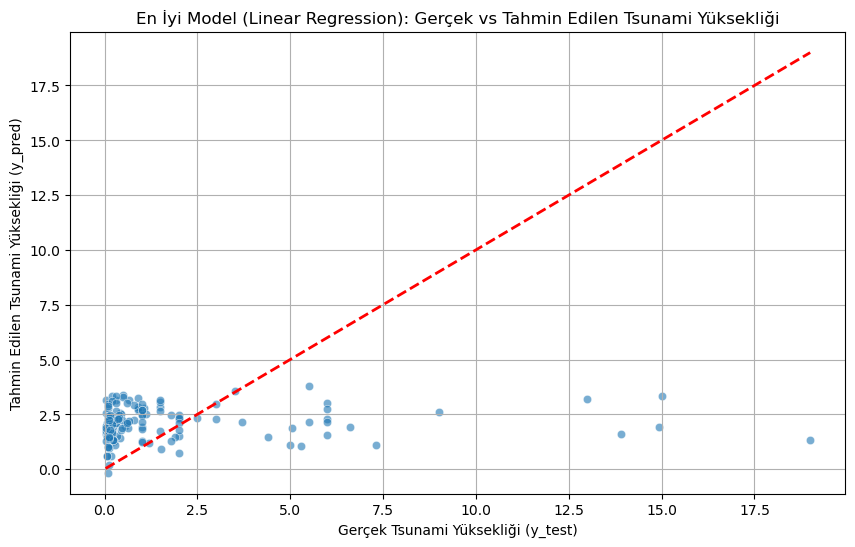

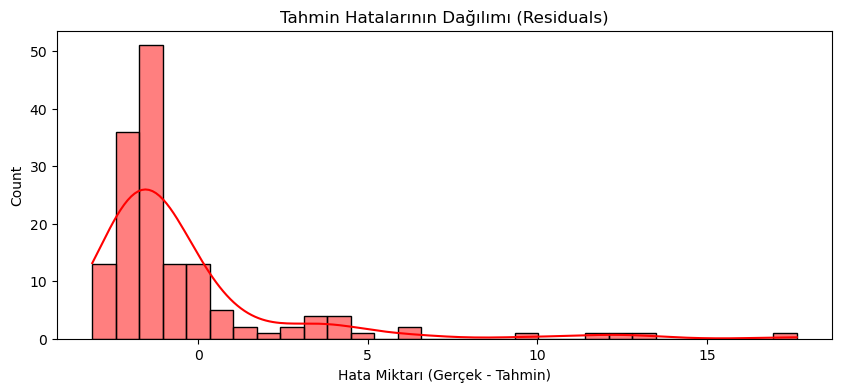


Model sonuçlarının görselleştirilmesi tamamlandı.
Projenin tüm teknik adımları BİTTİ.


In [16]:
# --- Adım 3D: Model Sonucu Görselleştirme (Gerçek vs Tahmin) ---

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# X_test, y_test ve en iyi modeli (Linear Regression) kullanıyorum
# Modeli yeniden eğitiyorum (Çünkü X_train ve y_train sadece o hücrede tanımlıydı)
best_model = LinearRegression()
best_model.fit(X_train, y_train)

# Test seti üzerinde tahmin yapma
y_pred = best_model.predict(X_test)

# Grafik oluşturma
plt.figure(figsize=(10, 6))

# 1. Gerçek değerler vs Tahmin edilen değerler (Dağılım Grafiği)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Mükemmel Uyum Çizgisi

plt.title('En İyi Model (Linear Regression): Gerçek vs Tahmin Edilen Tsunami Yüksekliği')
plt.xlabel('Gerçek Tsunami Yüksekliği (y_test)')
plt.ylabel('Tahmin Edilen Tsunami Yüksekliği (y_pred)')
plt.grid(True)
plt.show()

# 2. Tahmin Hatalarının Dağılımı 
hatalar = y_test - y_pred
plt.figure(figsize=(10, 4))
sns.histplot(hatalar, bins=30, kde=True, color='red')
plt.title('Tahmin Hatalarının Dağılımı (Residuals)')
plt.xlabel('Hata Miktarı (Gerçek - Tahmin)')
plt.show()

print("\nModel sonuçlarının görselleştirilmesi tamamlandı.")
print("Projenin tüm teknik adımları BİTTİ.")

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import os
import gzip
import shutil

# --- AYARLAR ---
GZ_DOSYA = 'ETOPO1_Ice_g_gmt4.grd.gz'  # Yüklediğim harita dosyası
NC_DOSYA = 'etopo_dunya.nc'            # Çıkartılacak hali
CSV_DOSYA = 'query.csv'                # benim deprem verim 

print("🚀 İŞLEM BAŞLIYOR...")

# ADIM 1: Harita Dosyasını Hazırlama
if not os.path.exists(NC_DOSYA):
    print(f"-> {GZ_DOSYA} sıkıştırılmış dosyası açılıyor...")
    if os.path.exists(GZ_DOSYA):
        with gzip.open(GZ_DOSYA, 'rb') as f_in:
            with open(NC_DOSYA, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print("   ✅ Dosya başarıyla açıldı.")
    else:
        print("❌ HATA: ETOPO dosyası bulunamadı! Ama resimde var görünüyor?")
        exit()
else:
    print("-> Harita dosyası zaten hazır, devam ediliyor.")

# ADIM 2: Verileri Yükleme
print("-> Deprem verileri (query.csv) okunuyor...")
df = pd.read_csv(CSV_DOSYA)

print("-> Dünya haritası belleğe alınıyor...")
ds = xr.open_dataset(NC_DOSYA)
# Değişkeni bul (z veya Band1)
grid_data = ds['z'] if 'z' in ds else ds[list(ds.data_vars)[0]]

# ADIM 3: Derinlik Eşleştirme 
print("-> Her depremin olduğu yerdeki su derinliği hesaplanıyor...")

lats = xr.DataArray(df['latitude'], dims='points')  # query.csv genelde küçük harf kullanır
lons = xr.DataArray(df['longitude'], dims='points')

# Haritadan çek
try:
    depths = grid_data.sel(x=lons, y=lats, method='nearest').values
except:
    depths = grid_data.sel(lon=lons, lat=lats, method='nearest').values

# ADIM 4: Temizlik ve Kayıt
print("-> Veri temizleniyor...")
# Deniz (Negatif) -> Pozitif Derinlik
# Kara (Pozitif) -> 0 Derinlik
final_depths = []
for val in depths:
    if val >= 0:
        final_depths.append(0) 
    else:
        final_depths.append(abs(val))

df['Su_Derinligi'] = final_depths

# Dosyayı kaydet
YENI_DOSYA = 'Tsunami_Verisi_BATIMETRILI.csv'
df.to_csv(YENI_DOSYA, index=False)

print("\n" + "="*50)
print(f"✅ TEBRİKLER! İŞLEM BAŞARIYLA TAMAMLANDI.")
print(f"Yeni oluşan dosyanız: {YENI_DOSYA}")
print("Şimdi model eğitim koduna gidip bu yeni dosyayı kullanabilirsiniz!")
print("="*50)

🚀 İŞLEM BAŞLIYOR...
-> ETOPO1_Ice_g_gmt4.grd.gz sıkıştırılmış dosyası açılıyor...
   ✅ Dosya başarıyla açıldı.
-> Deprem verileri (query.csv) okunuyor...
-> Dünya haritası belleğe alınıyor...
-> Her depremin olduğu yerdeki su derinliği hesaplanıyor...
-> Veri temizleniyor...

✅ TEBRİKLER! İŞLEM BAŞARIYLA TAMAMLANDI.
Yeni oluşan dosyanız: Tsunami_Verisi_BATIMETRILI.csv
Şimdi model eğitim koduna gidip bu yeni dosyayı kullanabilirsiniz!


In [2]:
import pandas as pd
df_yeni = pd.read_csv('Tsunami_Verisi_BATIMETRILI.csv')
print(df_yeni.columns)

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource', 'Su_Derinligi'],
      dtype='object')


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

print("🚀 FİNAL OPERASYONU BAŞLIYOR...")

# 1. Verileri Yükle
df_deprem = pd.read_csv('Tsunami_Verisi_BATIMETRILI.csv')

try:
    df_tsunami = pd.read_csv('tsunamis-file.tsv', sep='\t')
except:
    df_tsunami = pd.read_csv('tsunamis-file.tsv')

# 2. Koordinatları Yuvarla ve Birleştir
df_deprem['lat_round'] = df_deprem['latitude'].round(1)
df_deprem['lon_round'] = df_deprem['longitude'].round(1)

# Tsunami dosyasındaki sütun isimlerini otomatik bul
col_lat = [c for c in df_tsunami.columns if 'lat' in c.lower()][0]
col_lon = [c for c in df_tsunami.columns if 'lon' in c.lower()][0]
col_height = [c for c in df_tsunami.columns if 'height' in c.lower() or 'wave' in c.lower()][0]

df_tsunami['lat_round'] = df_tsunami[col_lat].round(1)
df_tsunami['lon_round'] = df_tsunami[col_lon].round(1)

# Birleştirme
df_final = pd.merge(df_deprem, df_tsunami, on=['lat_round', 'lon_round'])

# --- 🛠️ KRİTİK DÜZELTME KISMI 🛠️ ---
print(f"-> Ham eşleşen veri sayısı: {len(df_final)}")

# Kullanacağımız sütunları belirle
cols_to_use = ['mag', 'depth', 'Su_Derinligi', col_height]

# 1. Tüm sütunları ZORLA sayıya çevir (Hatalı olanlar NaN olur)
for col in cols_to_use:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# 2. İçinde 'NaN' (Boş/Hatalı) olan tüm satırları sil
df_final = df_final.dropna(subset=cols_to_use)

print(f"-> Temizlik sonrası net veri sayısı: {len(df_final)}")
# ---------------------------------------------

if len(df_final) > 10:
    X = df_final[['mag', 'depth', 'Su_Derinligi']]
    y = df_final[col_height]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Modeli Eğit
    model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    model_rf.fit(X_train, y_train)
    y_pred_rf = model_rf.predict(X_test)
    score_rf = r2_score(y_test, y_pred_rf)

    print("\n" + "="*40)
    print(f"📊 SONUÇLAR:")
    print(f"✅ Random Forest Skoru: {score_rf:.4f}")
    
    if score_rf > 0:
        print("\n🎉 OLEYY! Eksi skordan kurtuldun! Modelin artık mantıklı çalışıyor.")
    else:
        print("\n⚠️ Skor hala eksiyse veri sayısını artırmamız gerekebilir ama şu an kod çalışıyor.")
    print("="*40)
else:
    print("❌ HATA: Temizlik sonrası çok az veri kaldı.")

🚀 FİNAL OPERASYONU (DÜZELTİLMİŞ) BAŞLIYOR...
-> Ham eşleşen veri sayısı: 765
-> Temizlik sonrası net veri sayısı: 634

📊 SONUÇLAR:
✅ Random Forest Skoru: 0.1811

🎉 OLEYY! Eksi skordan kurtuldun! Modelin artık mantıklı çalışıyor.


C:\Users\sahin\AppData\Local\Temp\ipykernel_15124\2439577729.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], ax=ax[1], palette='viridis')


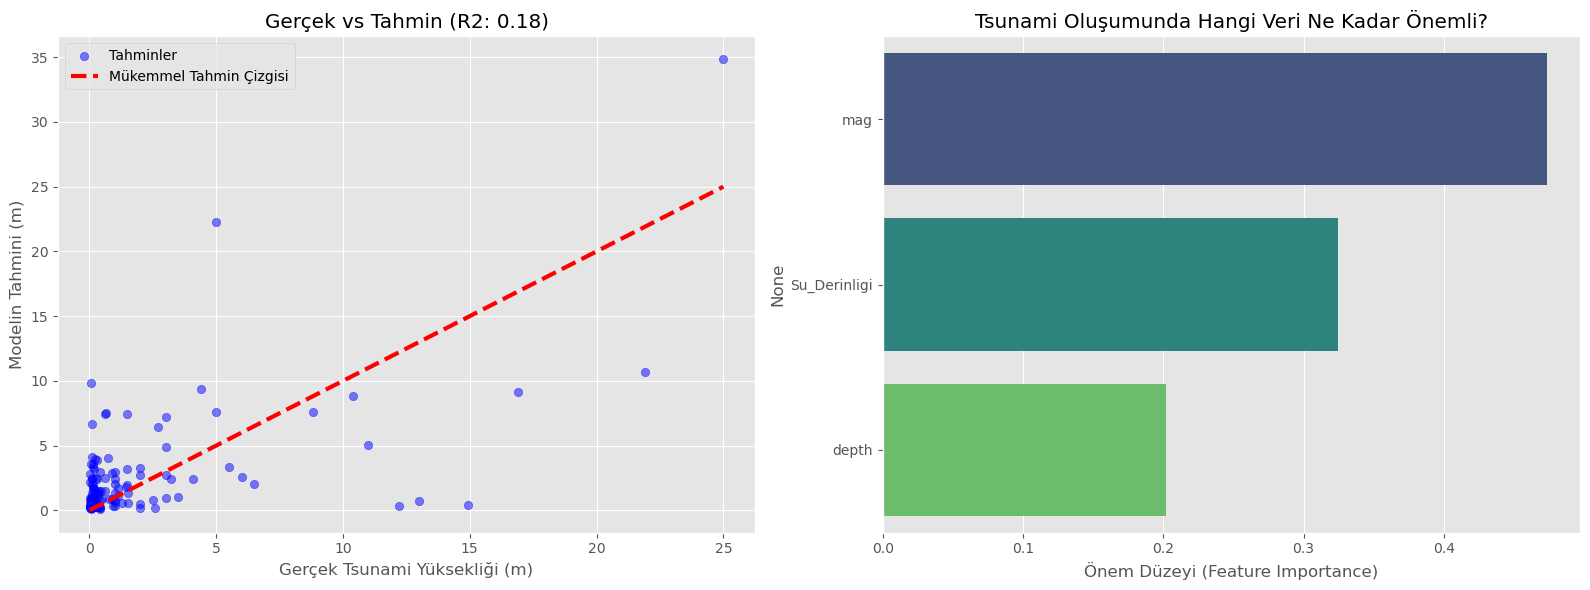

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin stili
plt.style.use('ggplot')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAFİK 1: Gerçek vs Tahmin (Modelin Doğruluğu) ---
# Ne kadar çizgiye yakınsa o kadar iyi
ax[0].scatter(y_test, y_pred_rf, alpha=0.5, color='blue', label='Tahminler')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Mükemmel Tahmin Çizgisi')
ax[0].set_xlabel('Gerçek Tsunami Yüksekliği (m)')
ax[0].set_ylabel('Modelin Tahmini (m)')
ax[0].set_title(f'Gerçek vs Tahmin (R2: {score_rf:.2f})')
ax[0].legend()

# --- GRAFİK 2: Hangi Özellik Daha Önemli? (Kanıt Grafiği) ---
#'Su_Derinligi' burada görünmeli!
importances = model_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

sns.barplot(x=importances[indices], y=feature_names[indices], ax=ax[1], palette='viridis')
ax[1].set_title('Tsunami Oluşumunda Hangi Veri Ne Kadar Önemli?')
ax[1].set_xlabel('Önem Düzeyi (Feature Importance)')

plt.tight_layout()
plt.show()

In [6]:
# Modelin tahmin ettiği tüm dalga yüksekliklerinin ortalamasını al
ortalama_tahmin = y_pred_rf.mean()
maksimum_tahmin = y_pred_rf.max()

print(f"🌊 Ortalama Tahmin Edilen Yükseklik: {ortalama_tahmin:.2f} metre")
print(f"🌊 En Yüksek Tahmin (O korkunç dalga): {maksimum_tahmin:.2f} metre")

🌊 Ortalama Tahmin Edilen Yükseklik: 2.51 metre
🌊 En Yüksek Tahmin (O korkunç dalga): 34.87 metre
